# House price prediction
## 1. Business objective
* **Develop a machine learning model that predicts the selling price of a house based on its features** 
* **Identify the key factors that influence house prices**
* **Support buyers, sellers, and real estate professionals in making data-driven decisions**
* **Improve pricing accuracy and reduce the risk of underpricing or overpricing properties**
  * **Problem Type:** Supervised learning
  * **Task:** Regression

## 2. Data understanding

  

In [1]:
import pandas as pd
df = pd.read_csv("D:/ML_projects/HousePricePrediction/HousePricePrediction.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,07-05-2014 00:00,599999.0,9,4.50,3830,6988,2.5,0,0,3,2450,1380,1938,2003,8809 Densmore Ave N,Seattle,WA 98103,USA
1,28-05-2014 00:00,1970000.0,8,3.50,4440,6480,2.0,0,3,5,3140,1300,1959,0,1210 22nd Ave E,Seattle,WA 98112,USA
2,03-07-2014 00:00,340000.0,8,2.75,2790,6695,1.0,0,0,3,1470,1320,1977,2004,17512 Corliss Ave N,Shoreline,WA 98133,USA
3,07-05-2014 00:00,3200000.0,7,4.50,6210,8856,2.5,0,2,5,4760,1450,1910,0,1230 Warren Ave N,Seattle,WA 98109,USA
4,05-05-2014 00:00,2280000.0,7,8.00,13540,307752,3.0,0,4,3,9410,4130,1999,0,26408 NE 70th St,Redmond,WA 98053,USA


In [2]:
df.shape     # The Dataset has 4600 observations of 18 features

(4600, 18)

In [3]:
df.info()       # There is no missing values in any columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   int64  
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
price,4600.0,551962.99,563834.70,0.0,322875.00,460943.46,654962.50,26590000.0
bedrooms,4600.0,3.40,0.91,0.0,3.00,3.00,4.00,9.0
bathrooms,4600.0,2.16,0.78,0.0,1.75,2.25,2.50,8.0
sqft_living,4600.0,2139.35,963.21,370.0,1460.00,1980.00,2620.00,13540.0
sqft_lot,4600.0,14852.52,35884.44,638.0,5000.75,7683.00,11001.25,1074218.0
floors,4600.0,1.51,0.54,1.0,1.00,1.50,2.00,3.5
waterfront,4600.0,0.01,0.08,0.0,0.00,0.00,0.00,1.0
view,4600.0,0.24,0.78,0.0,0.00,0.00,0.00,4.0
condition,4600.0,3.45,0.68,1.0,3.00,3.00,4.00,5.0
sqft_above,4600.0,1827.27,862.17,370.0,1190.00,1590.00,2300.00,9410.0


In [5]:
df.describe(include='object')

,date,street,city,statezip,country
count,4600,4600,4600,4600,4600
unique,70,4525,44,77,1
top,23-06-2014 00:00,2520 Mulberry Walk NE,Seattle,WA 98103,USA
freq,142,4,1573,148,4600


In [6]:
df.nunique()

date               70
price            1741
bedrooms           10
bathrooms          26
sqft_living       566
sqft_lot         3113
floors              6
waterfront          2
view                5
condition           5
sqft_above        511
sqft_basement     207
yr_built          115
yr_renovated       60
street           4525
city               44
statezip           77
country             1
dtype: int64

In [7]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols        # there are 5 categorical column

Index(['date', 'street', 'city', 'statezip', 'country'], dtype='object')

In [8]:
num_cols = df.select_dtypes(include=['int','float']).columns
num_cols       # there are 13 numerical columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated'],
      dtype='object')

In [9]:
df.duplicated().sum()    # there is no duplicate values

0

### Note :
* There is no missing values but 'price' and 'sqft_basement' has minimum value as 0
* There is no duplicate values
* Column 'country' has only one canstant value 'USA' and 'statezip' also does not carry any information
* 'street' has 4525 unique values in 4600 values so this also does not give any information
* There is only 70 days sales price data we have
* 'bedrooms', 'bathrooms', 'floors' are in decimel
* sqft_living = sqft_above + sqft_basement

## 3. Exploratory Data Analysis

In [10]:
price_0 =len(df[df['price'] == 0])
print(f"'price' has {price_0} observations with 0")

df_eda = df[df['price']>0].copy()
df_eda.shape

'price' has 49 observations with 0


(4551, 18)

In [11]:
df_eda["price"].describe().round()

count        4551.0
mean       557906.0
std        563930.0
min          7800.0
25%        326264.0
50%        465000.0
75%        657500.0
max      26590000.0
Name: price, dtype: float64

In [12]:
df_eda[df_eda.price == 7800]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
4554,06-05-2014 00:00,7800.0,2,1.0,780,16344,1.0,0,0,1,780,0,1942,0,4229 S 144th St,Tukwila,WA 98168,USA


In [13]:
sqft_basement_0 = len(df[df['sqft_basement'] == 0])
print(f"'sqft_basement' has {sqft_basement_0} observations with 0")

'sqft_basement' has 2745 observations with 0


In [14]:
df_eda.yr_built.max()

2014

In [15]:
df_eda.yr_built.min()

1900

In [16]:
df_eda.yr_built.nunique()

115

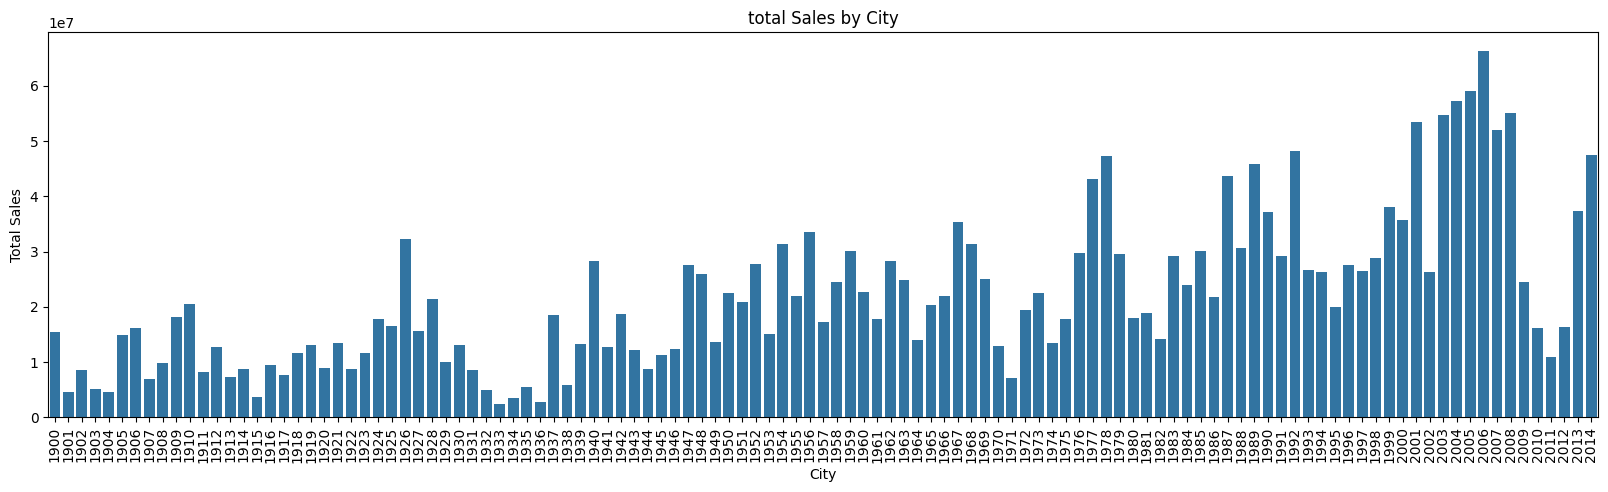

In [17]:
import matplotlib.pyplot as plt
import seaborn as sb
year_sales = df_eda.groupby("yr_built")["price"].sum().sort_values(ascending=False)

plt.figure(figsize=(20,5))
sb.barplot(x=year_sales.index, y=year_sales.values)
plt.title("total Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()

     yr_built  sales_count
0        1900           22
1        1901            9
2        1902           10
3        1903           10
4        1904            9
..        ...          ...
110      2010           28
111      2011           24
112      2012           33
113      2013           55
114      2014           78

[115 rows x 2 columns]


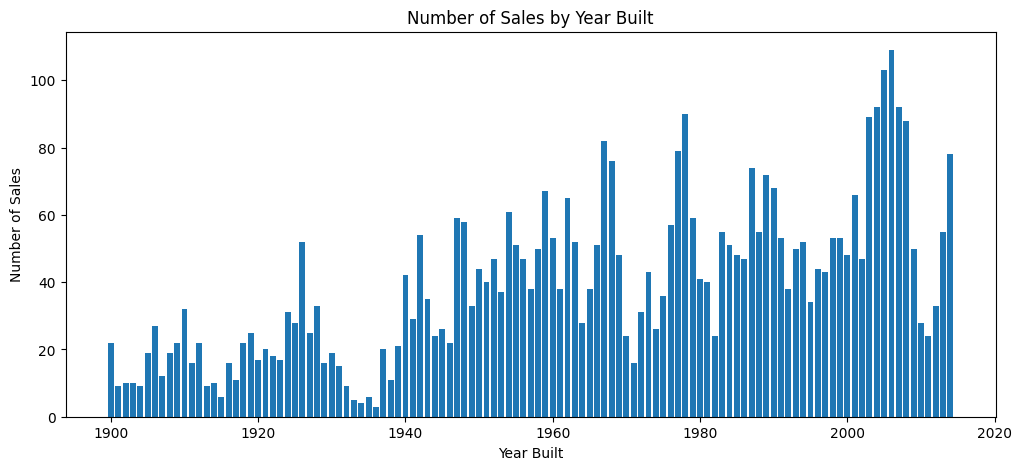

In [18]:
import matplotlib.pyplot as plt
sales_by_year = (
    df_eda['yr_built']
    .value_counts()
    .sort_index()
    .reset_index()
)

sales_by_year.columns = ['yr_built', 'sales_count']

print(sales_by_year)
plt.figure(figsize=(12, 5))

plt.bar(
    sales_by_year['yr_built'],
    sales_by_year['sales_count']
)

plt.xlabel('Year Built')
plt.ylabel('Number of Sales')
plt.title('Number of Sales by Year Built')

plt.show()

In [19]:
df_eda.drop(columns=['street','country','statezip'], inplace=True)
df_eda.shape


(4551, 15)

In [20]:
df_eda = df_eda.astype({'bedrooms':'int','bathrooms':'int','floors':'int'})
df_eda['date'] = pd.to_datetime(df_eda['date'],   format="%d-%m-%Y %H:%M")
df_eda.dtypes

date             datetime64[ns]
price                   float64
bedrooms                  int32
bathrooms                 int32
sqft_living               int64
sqft_lot                  int64
floors                    int32
waterfront                int64
view                      int64
condition                 int64
sqft_above                int64
sqft_basement             int64
yr_built                  int64
yr_renovated              int64
city                     object
dtype: object

In [21]:
(df_eda.sqft_living == df_eda.sqft_above + df_eda.sqft_basement).all()
#sqft_living is exactly equal to sqft_above + sqft_basement for all rows. so this is linearly dependent variable

True

In [22]:
df_eda.date.dt.year.value_counts()

date
2014    4551
Name: count, dtype: int64

In [23]:
df_eda.date.dt.month_name().value_counts()

date
June    2155
May     1748
July     648
Name: count, dtype: int64

In [24]:
df_eda.date.dt.day_name().value_counts()

date
Tuesday      1053
Wednesday     997
Thursday      842
Monday        819
Friday        711
Saturday       65
Sunday         64
Name: count, dtype: int64

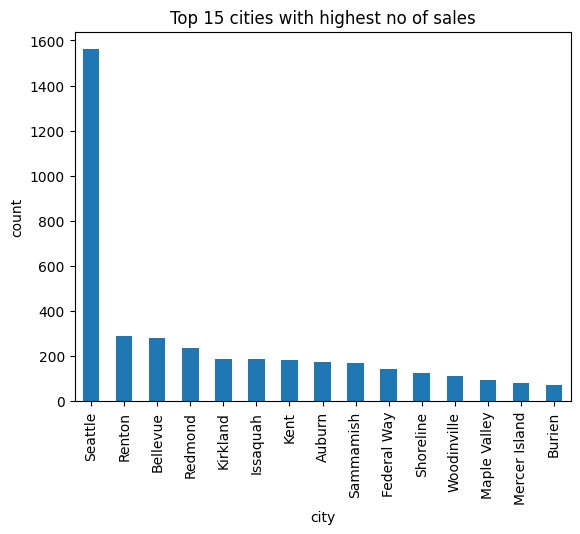

In [25]:

ax = df_eda.city.value_counts()\
.head(15)\
.plot(kind='bar', title = 'Top 15 cities with highest no of sales')
ax.set_ylabel('count')
plt.show()

In [26]:
city_counts = df_eda['city'].value_counts()[df_eda['city'].value_counts()>20]
city_counts

city
Seattle             1561
Renton               291
Bellevue             281
Redmond              235
Kirkland             187
Issaquah             186
Kent                 184
Auburn               175
Sammamish            171
Federal Way          145
Shoreline            123
Woodinville          114
Maple Valley          95
Mercer Island         82
Burien                72
Snoqualmie            69
Kenmore               65
Des Moines            58
North Bend            50
Covington             42
Duvall                42
Lake Forest Park      34
Newcastle             33
Bothell               33
Tukwila               29
Vashon                29
SeaTac                28
Enumclaw              27
Carnation             22
Name: count, dtype: int64

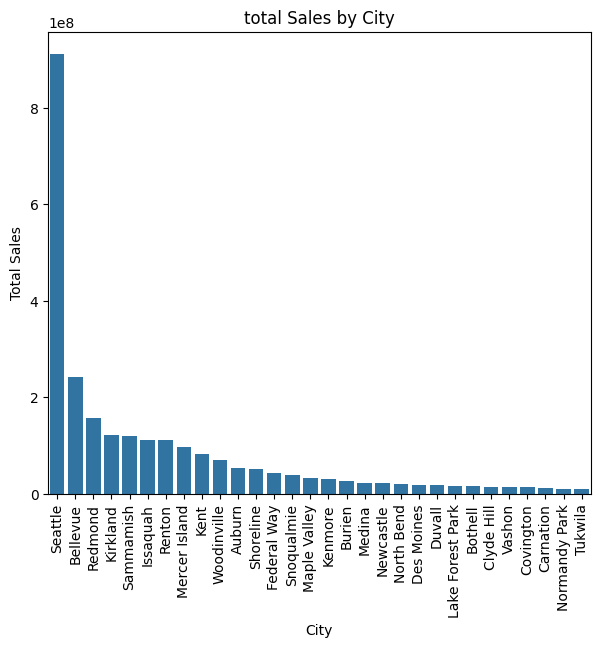

In [27]:
city_sales = df_eda.groupby("city")["price"].sum().sort_values(ascending=False).head(30)
plt.figure(figsize=(7,6))
sb.barplot(x=city_sales.index, y=city_sales.values)
plt.title("total Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()

In [28]:
df_eda["waterfront"].value_counts()

waterfront
0    4521
1      30
Name: count, dtype: int64

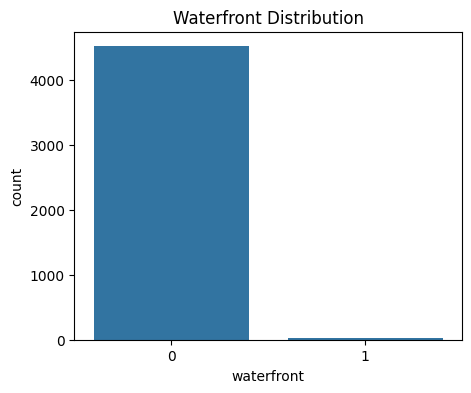

In [29]:
plt.figure(figsize=(5,4))
sb.countplot(data=df_eda, x="waterfront")
plt.title("Waterfront Distribution")
plt.show()


In [30]:
df_eda.groupby("waterfront")["price"].median().map("{:,.0f}".format)

waterfront
0      464,000
1    1,072,500
Name: price, dtype: object

In [31]:
df_eda["view"].value_counts().sort_index()

view
0    4103
1      69
2     201
3     115
4      63
Name: count, dtype: int64

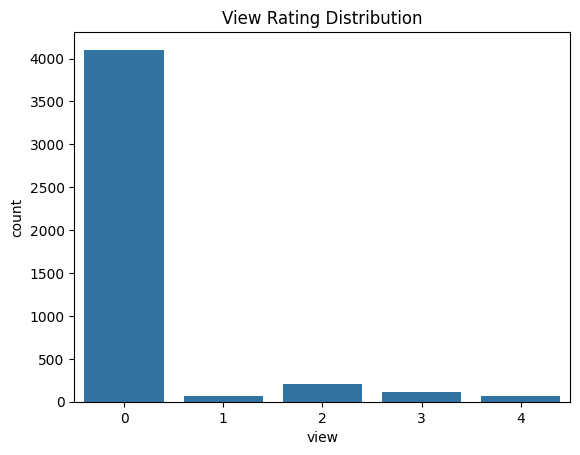

In [32]:
sb.countplot(data=df_eda, x="view")
plt.title("View Rating Distribution")
plt.show()

In [33]:
df_eda["condition"].value_counts().sort_index()

condition
1       6
2      31
3    2851
4    1238
5     425
Name: count, dtype: int64

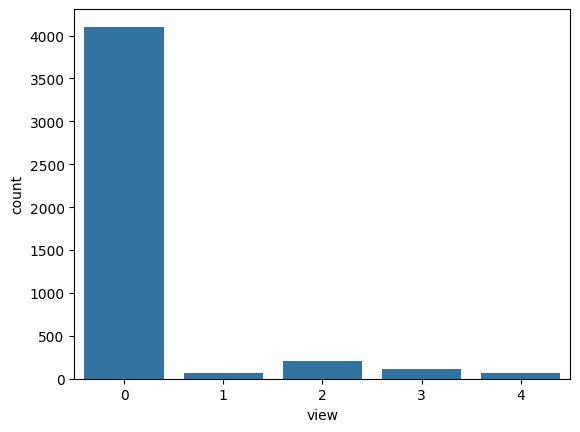

view
0      445,000
1      719,000
2      664,950
3      900,000
4    1,149,000
Name: price, dtype: object

In [34]:
sb.countplot(data=df_eda, x = "view")
plt.show()
df_eda.groupby("view")["price"].median()\
.map("{:,.0f}".format)

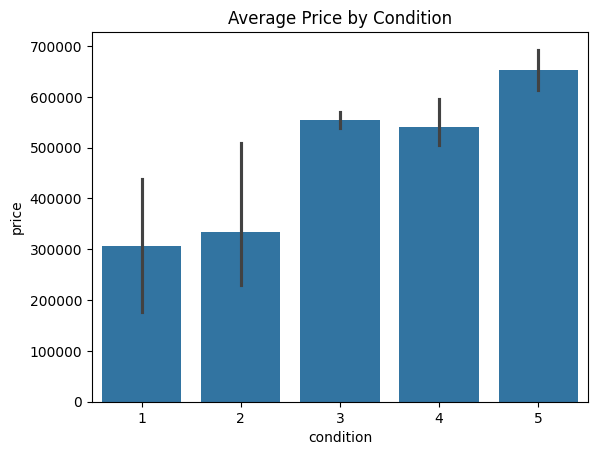

In [35]:

sb.barplot(
    data=df_eda,
    x="condition",
    y="price",
   
)

plt.title("Average Price by Condition")
plt.show()

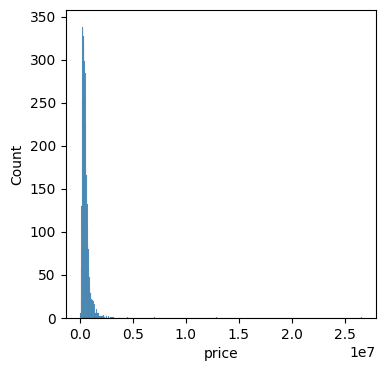

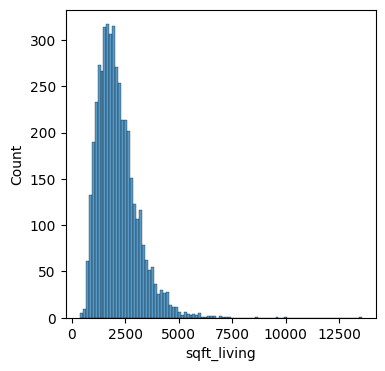

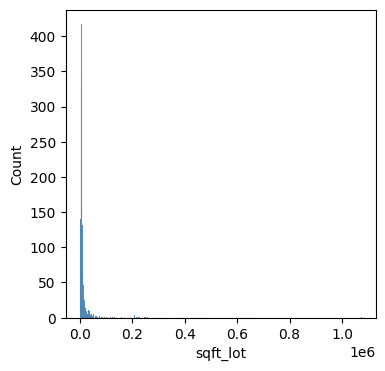

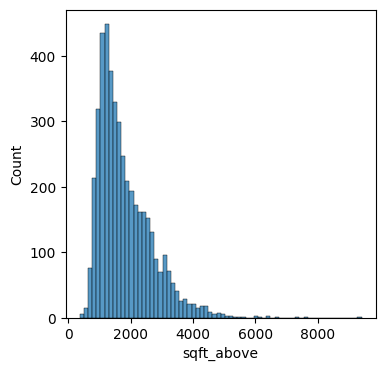

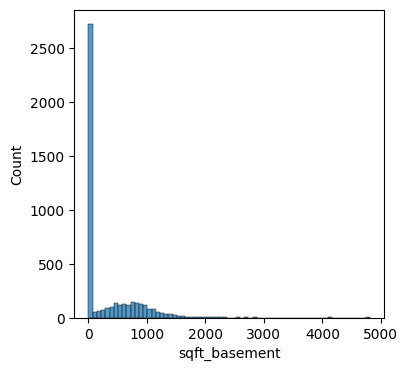

In [36]:

dist = ['price','sqft_living','sqft_lot','sqft_above','sqft_basement']
for i in dist:
  plt.figure(figsize=(4,4))
  sb.histplot(data= df_eda, x=i)
  plt.show()

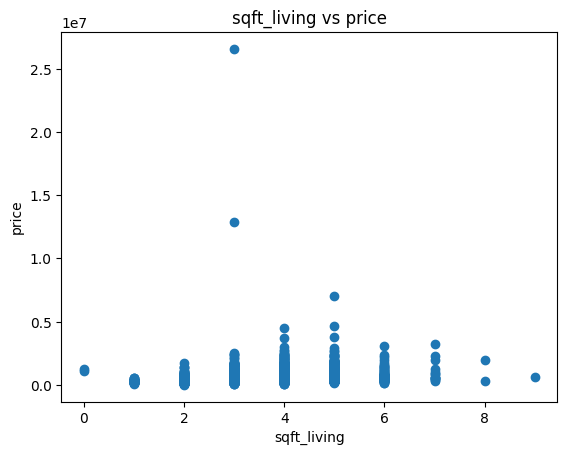

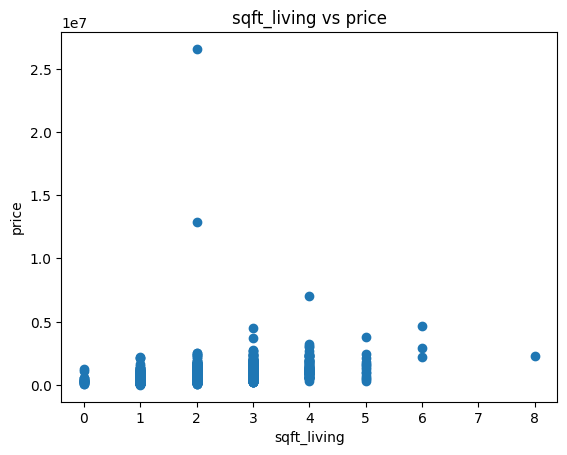

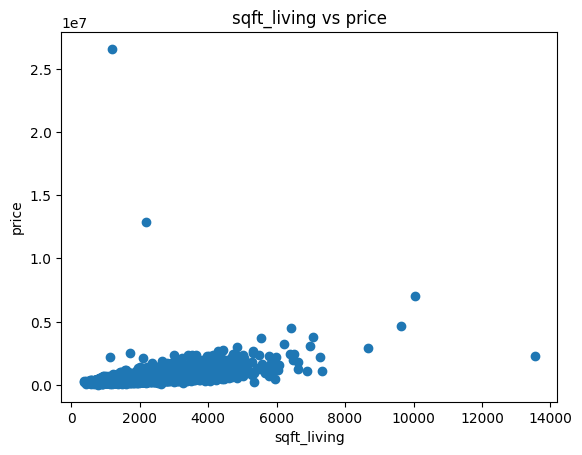

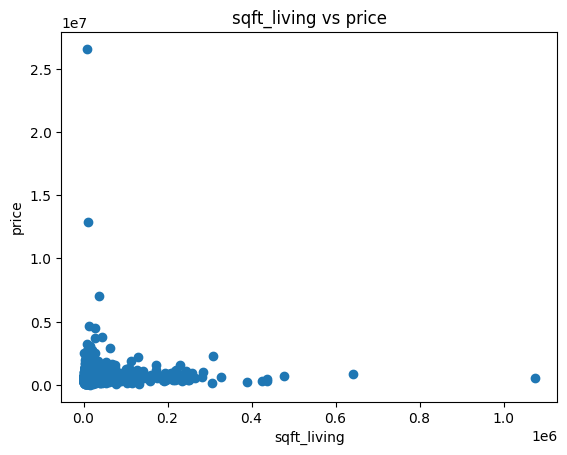

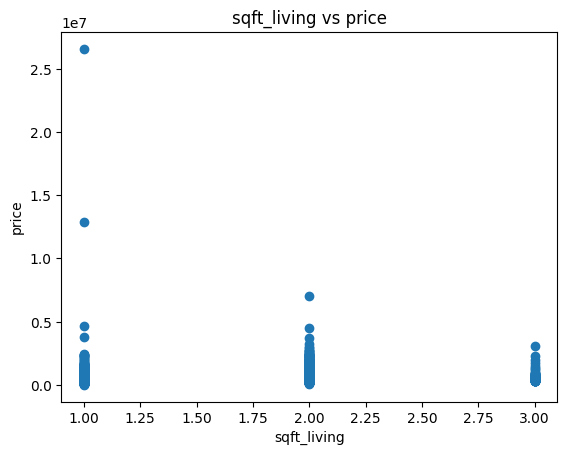

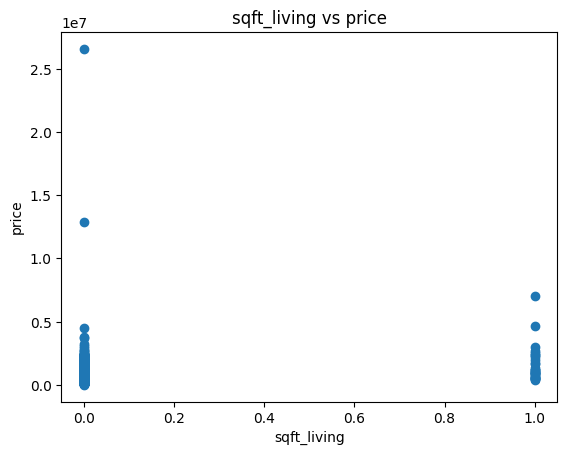

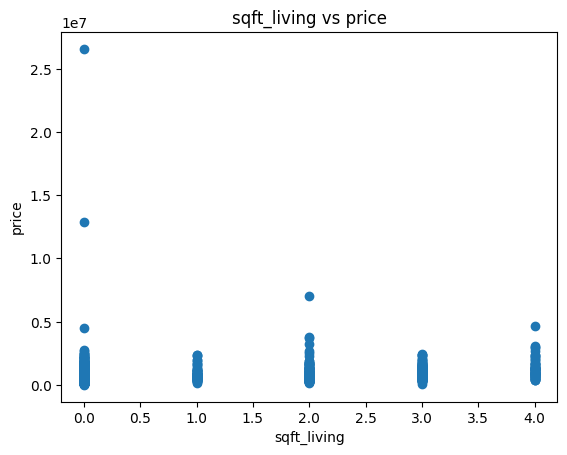

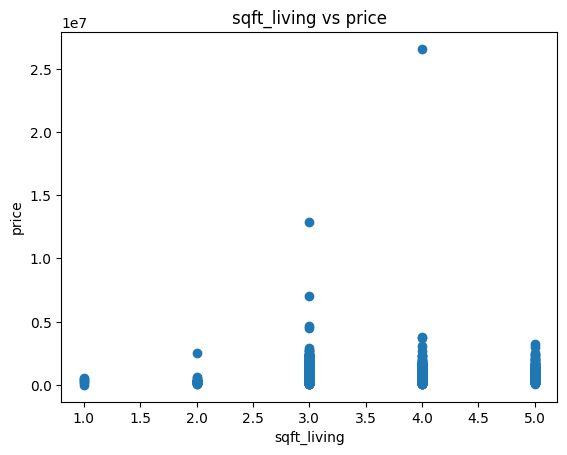

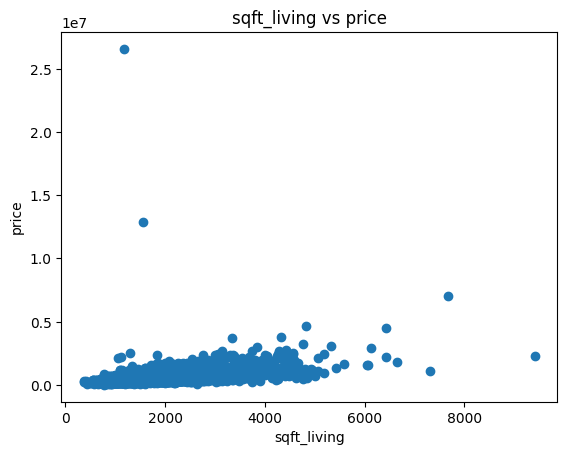

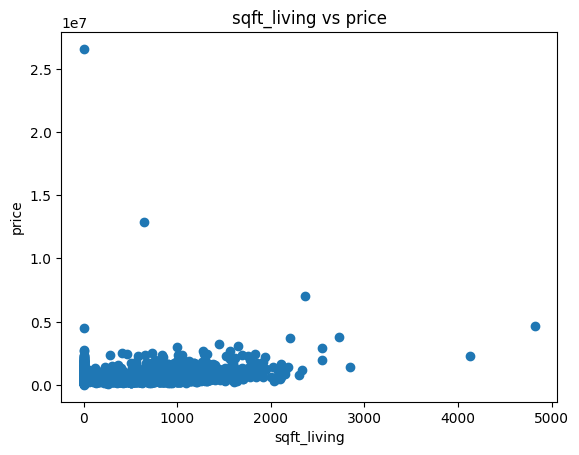

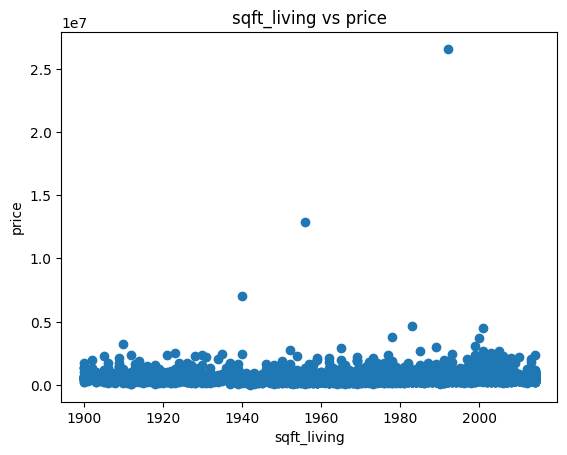

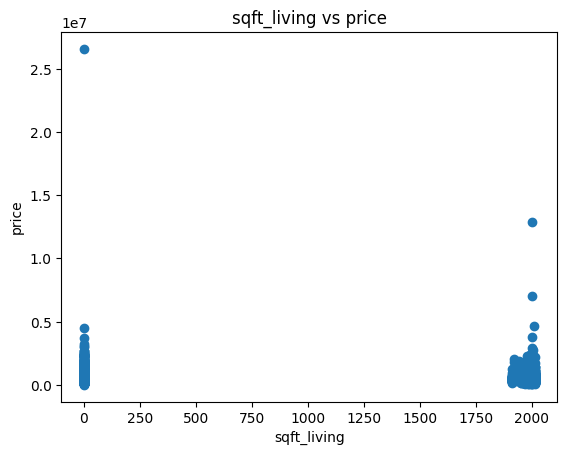

In [37]:
scat=['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated']
for i in scat:
  plt.scatter(df_eda[i], df_eda["price"])
  plt.xlabel("sqft_living")
  plt.ylabel("price")
  plt.title("sqft_living vs price")
  plt.show()

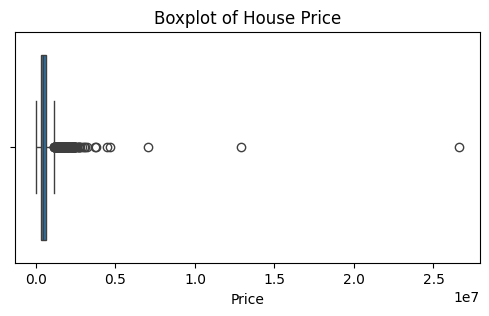

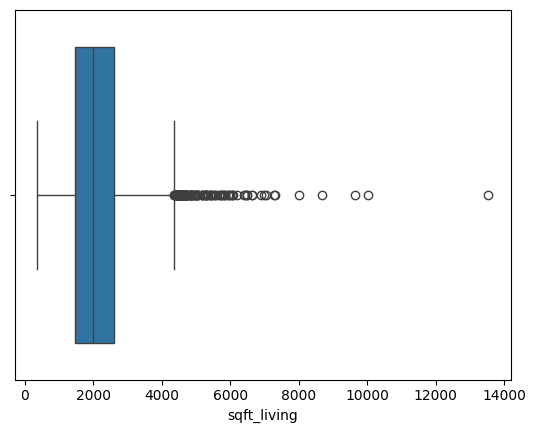

In [38]:


plt.figure(figsize=(6,3))

sb.boxplot(x=df['price'])

plt.title('Boxplot of House Price')
plt.xlabel('Price')
plt.show()
sb.boxplot(x=df['sqft_living'])
plt.show()

In [39]:
import numpy as np

median = df_eda['price'].median()

MAD = np.median(
    np.abs(df_eda['price'] - median)
)

modified_z = 0.6745 * (
    (df_eda['price'] - median) / MAD
)

outliers_pr = df_eda[np.abs(modified_z) > 3.5]

print("Number of outliers:", len(outliers_pr))
df_clean = df_eda[modified_z.abs() <= 3.5].copy()
print("Original rows:", len(df_eda))
print("After removal:", len(df_clean))
print("Removed:", len(df_eda) - len(df_clean))

Number of outliers: 184
Original rows: 4551
After removal: 4367
Removed: 184


In [40]:
import numpy as np

# Median
median = df_clean['sqft_living'].median()

# MAD (Median Absolute Deviation)
MAD = np.median(
    np.abs(df_clean['sqft_living'] - median)
)

# Modified Z-score
modified_z = 0.6745 * (
    (df_clean['sqft_living'] - median) / MAD
)

# Identify outliers
outliers_sqft = df_clean[
    modified_z.abs() > 3.5
]

print("Median:", median)
print("MAD:", MAD)
print("Number of sqft_living outliers:", len(outliers_sqft))
print(outliers_sqft['sqft_living'].sort_values())
df_new=df_clean[
    modified_z.abs() <= 3.5
].copy()


Median: 1930.0
MAD: 530.0
Number of sqft_living outliers: 30
1125    4690
664     4700
2073    4720
537     4740
583     4740
151     4850
259     4850
2016    4910
529     4910
743     4930
941     5010
561     5070
142     5180
166     5190
805     5270
162     5330
413     5340
526     5420
128     5430
514     5520
625     5660
524     5730
208     5774
548     5860
551     5940
323     5960
29      6040
6       6630
30      6900
135     7320
Name: sqft_living, dtype: int64


In [41]:
print("Original rows:", len(df_clean))
print("Rows after removing outliers:", len(df_new))

Original rows: 4367
Rows after removing outliers: 4337


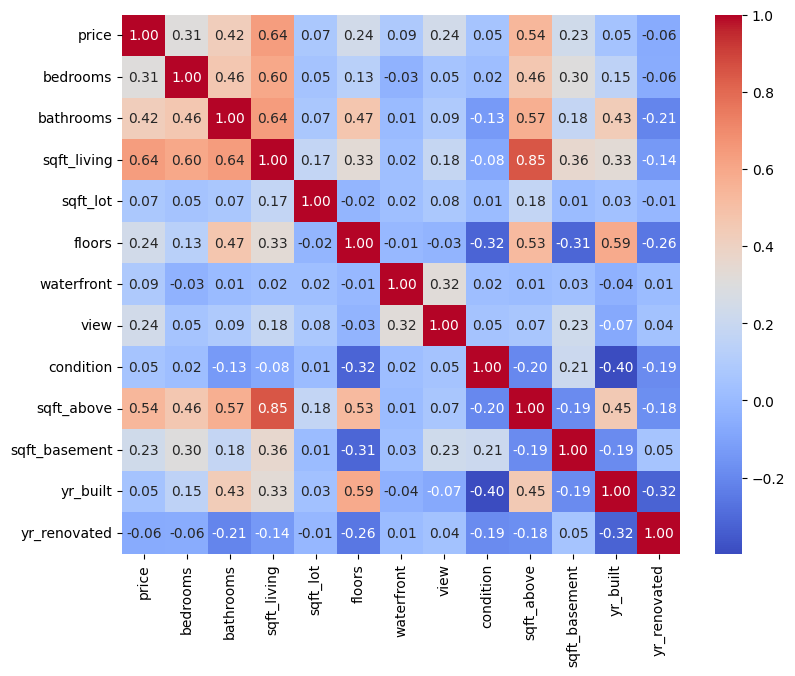

In [42]:
plt.figure(figsize=(9,7))
sb.heatmap(df_new[num_cols].corr(),annot=True,fmt='.2f', cmap='coolwarm')
plt.show()

### Insights from EDA :
*  we have only 3 month's(May,June,July) sales data in 2014
*  May and June have high sales count
*  compared to weekends , weekdays have more sales count
*  city 'Seattle' has highest number of sales 
*  'price' has the right skewed distribution
*  There is no much correlation between price and 'yr_built', 'yr_renovated', 'condition' and 'sqft_lot'

  

## 4. Feature Engineering

In [43]:
df_new["sale_year"] = pd.to_datetime(df_new["date"]).dt.year
df_new["age"] = df_new["sale_year"] - df_new["yr_built"]


In [44]:
bins = [1900, 1916, 1932, 1948, 1964, 1980, 1996, 2014]

labels = [
    '1900-1916',
    '1917-1932',
    '1933-1948',
    '1949-1964',
    '1965-1980',
    '1981-1996',
    '1997-2014'
]

df_new['yr_built_bin'] = pd.cut(
    df_new['yr_built'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(df_new[['yr_built', 'yr_built_bin']].head())

   yr_built yr_built_bin
0      1938    1933-1948
2      1977    1965-1980
7      1957    1949-1964
8      1982    1981-1996
9      1964    1949-1964


In [45]:
df_new.yr_renovated.value_counts().sort_index()

yr_renovated
0       2572
1912      33
1913       1
1923      51
1934       6
1945       5
1948       1
1953       1
1954       8
1955       2
1956      14
1958       5
1960       1
1963      12
1966       1
1968       9
1969      11
1970       9
1971       5
1972      17
1974       6
1977       1
1978       3
1979      30
1980       2
1981       1
1982      22
1983      39
1984       9
1985      28
1986       4
1987       1
1988      41
1989      52
1990      13
1992      31
1993      36
1994      54
1995       1
1996      20
1997      28
1998      38
1999      37
2000     163
2001     102
2002      36
2003     137
2004      75
2005      90
2006      63
2007       6
2008      45
2009     103
2010      29
2011      54
2012      45
2013      60
2014      68
Name: count, dtype: int64

In [46]:
df_new["renovated"] = (df_new["yr_renovated"]>0).astype('int')
df_new.renovated.value_counts()

renovated
0    2572
1    1765
Name: count, dtype: int64

In [47]:
df_new.renovated.corr(df_new.price)

-0.06389878120353912

In [48]:
df_new["total_rooms"] = df_new.bedrooms + df_new.bathrooms

In [49]:
df_new["total_rooms"].corr(df_new.price)

0.4172646308014475

In [50]:
df_new.drop(columns=['yr_built','date','yr_renovated','sale_year','bedrooms','bathrooms'],inplace=True)

In [51]:
df_new.head()

,price,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,city,age,yr_built_bin,renovated,total_rooms
0,599999.0,3830,6988,2,0,0,3,2450,1380,Seattle,76,1933-1948,1,13
2,340000.0,2790,6695,1,0,0,3,1470,1320,Shoreline,37,1965-1980,1,10
7,999000.0,3150,34830,1,0,0,3,3150,0,Bellevue,57,1949-1964,1,11
8,840000.0,4290,37607,1,0,0,5,4290,0,Issaquah,32,1981-1996,0,11
9,824000.0,3670,4000,2,0,1,3,2800,870,Seattle,50,1949-1964,1,11


In [52]:
df_new.describe().T.round()

,count,mean,std,min,25%,50%,75%,max
price,4337.0,493502.0,225698.0,7800.0,320000.0,450000.0,620000.0,1270000.0
sqft_living,4337.0,2027.0,783.0,370.0,1440.0,1930.0,2520.0,4680.0
sqft_lot,4337.0,14302.0,35440.0,638.0,5000.0,7560.0,10640.0,1074218.0
floors,4337.0,1.0,1.0,1.0,1.0,1.0,2.0,3.0
waterfront,4337.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
view,4337.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0
condition,4337.0,3.0,1.0,1.0,3.0,3.0,4.0,5.0
sqft_above,4337.0,1743.0,743.0,370.0,1170.0,1540.0,2200.0,4620.0
sqft_basement,4337.0,284.0,421.0,0.0,0.0,0.0,570.0,2330.0
age,4337.0,43.0,30.0,0.0,18.0,39.0,63.0,114.0


In [53]:
top_cities=city_counts.index
# Replace all other cities with "Others" 
df_new['city'] = df_new['city'].where( df_new['city'].isin(top_cities), 'Others' )
print(df_new['city'].value_counts())

city
Seattle             1482
Renton               288
Bellevue             238
Redmond              227
Kent                 183
Issaquah             180
Kirkland             178
Auburn               174
Sammamish            166
Federal Way          143
Shoreline            121
Woodinville          111
Maple Valley          95
Burien                72
Others                68
Snoqualmie            66
Kenmore               65
Mercer Island         58
Des Moines            58
North Bend            50
Duvall                41
Covington             41
Newcastle             33
Bothell               33
Lake Forest Park      33
Vashon                29
SeaTac                28
Tukwila               28
Enumclaw              27
Carnation             21
Name: count, dtype: int64


In [54]:
df_new['building_footprint'] = df_new['sqft_living'] / df_new['floors']

df_new['extra_area'] = (
    df_new['sqft_lot'] - df_new['building_footprint']
).astype(int)
df_new.extra_area.head()

df_new.drop('sqft_lot',inplace=True,axis=1)
df_new['extra_area'].corr(df_new['price'])

0.06778159587975989

In [58]:
# =========================================================
# MODEL SELECTION USING 5-FOLD CROSS VALIDATION
# XGBoost vs CatBoost vs Random Forest
# =========================================================

# Install CatBoost if needed
#!pip install catboost

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from catboost import CatBoostRegressor


# =========================================================
# 1. Features and Target
# =========================================================

X = df_new.drop(columns=['price'])
y = df_new['price']


# =========================================================
# 2. Train-Test Split
# Test set remains untouched
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=6
)

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)


# =========================================================
# 3. Define Columns
# =========================================================

cat_cols = [
    'city',
    'yr_built_bin'
]

num_cols = [
    'sqft_basement',
    'sqft_above',
    'total_rooms',
    'floors',
    'view',
    'waterfront',
    'condition',
    'renovated'
   #'age'
]


# =========================================================
# 4. Preprocessor for Tree-Based Models
# Scaling is NOT required
# =========================================================

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            num_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            cat_cols
        )
    ]
)


# =========================================================
# 5. Define Models
# =========================================================

models = {

    "XGBoost": Pipeline([
        ("preprocessing", tree_preprocessor),

        ("model", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            objective='reg:squarederror'
        ))
    ]),


    "CatBoost": Pipeline([
        ("preprocessing", tree_preprocessor),

        ("model", CatBoostRegressor(
            iterations=300,
            learning_rate=0.05,
            depth=6,
            loss_function='RMSE',
            random_seed=42,
            verbose=0
        ))
    ]),


    "Random Forest": Pipeline([
        ("preprocessing", tree_preprocessor),

        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        ))
    ])
}


# =========================================================
# 6. 5-Fold Cross Validation
# =========================================================

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# =========================================================
# 7. Model Selection
# =========================================================

cv_results = []

for name, model in models.items():

    print(f"\nRunning 5-Fold CV for: {name}")

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,

        scoring={
            'r2': 'r2',
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error'
        },

        n_jobs=-1
    )

    cv_results.append({

        'Model': name,

        'CV R² Mean':
            scores['test_r2'].mean(),

        'CV R² Std':
            scores['test_r2'].std(),

        'CV MAE Mean':
            -scores['test_mae'].mean(),

        'CV RMSE Mean':
            -scores['test_rmse'].mean()
    })


# =========================================================
# 8. Results
# =========================================================

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by='CV R² Mean',
    ascending=False
)

print("\nMODEL SELECTION RESULTS")
print("=" * 80)

print(cv_results_df.to_string(index=False))


# =========================================================
# 9. Best Baseline Model
# =========================================================

best_model_name = cv_results_df.iloc[0]['Model']

print("\nBest Baseline Model:", best_model_name)

Training shape: (3035, 14)
Testing shape : (1302, 14)

Running 5-Fold CV for: XGBoost

Running 5-Fold CV for: CatBoost

Running 5-Fold CV for: Random Forest

MODEL SELECTION RESULTS
        Model  CV R² Mean  CV R² Std  CV MAE Mean  CV RMSE Mean
     CatBoost    0.700201   0.010662 86186.849049 123725.957666
      XGBoost    0.684312   0.005274 87455.948545 126964.709590
Random Forest    0.660538   0.010979 92188.158752 131665.647951

Best Baseline Model: CatBoost


In [76]:
# =========================================================
# CATBOOST REGRESSION - HYPERPARAMETER TUNING
# =========================================================

import numpy as np

from catboost import CatBoostRegressor

from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# =========================================================
# 1. CatBoost Model
# =========================================================

catboost_model = CatBoostRegressor(
    random_seed=6,
    loss_function="RMSE",
    verbose=0
)


# =========================================================
# 2. Pipeline
# =========================================================

catboost_pipe = Pipeline([
    ("Preprocessing", tree_preprocessor),
    ("Model", catboost_model)
])


# =========================================================
# 3. Hyperparameter Search Space
# =========================================================

# =========================================================
# CATBOOST - REGULARIZATION FOCUSED TUNING
# =========================================================

# =========================================================
# CATBOOST - REDUCED MODEL COMPLEXITY
# =========================================================

# =========================================================
# CATBOOST - MODERATE MODEL COMPLEXITY
# =========================================================

param_grid = {

    # Moderate number of boosting iterations
    "Model__iterations": [ 500, 600, 700, 800],

    # Learning rate
    "Model__learning_rate": [0.001, 0.02, 0.03],

    # Moderate tree depth
    "Model__depth": [4, 5, 6, 7],

    # Moderate to strong regularization
    "Model__l2_leaf_reg": [5, 10, 15, 20, 30],

    # Randomness
    "Model__random_strength": [1, 2, 3, 5],

    # Bagging
    "Model__bagging_temperature": [2, 3, 5]
}


# =========================================================
# 4. Randomized Search
# =========================================================

catboost_search = RandomizedSearchCV(
    estimator=catboost_pipe,
    param_distributions=param_grid,
    n_iter=30,
    scoring="r2",
    cv=5,
    random_state=6,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)


# =========================================================
# 5. Fit
# =========================================================

catboost_search.fit(X_train, y_train)


# =========================================================
# 6. Best Parameters
# =========================================================

print("Best Parameters:")
print(catboost_search.best_params_)

print("\nBest CV R2:")
print(catboost_search.best_score_)


# =========================================================
# 7. Best Model
# =========================================================

best_catboost = catboost_search.best_estimator_


# =========================================================
# 8. Predictions
# =========================================================

train_pred = best_catboost.predict(X_train)
test_pred = best_catboost.predict(X_test)


# =========================================================
# 9. Evaluation Function
# =========================================================

def evaluate_model(y_true, y_pred, dataset_name):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    print(f"\n{dataset_name} Results")
    print("-" * 40)
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2  :", r2)

    return r2


# =========================================================
# 10. Train & Test Evaluation
# =========================================================

train_r2 = evaluate_model(
    y_train,
    train_pred,
    "Training"
)

test_r2 = evaluate_model(
    y_test,
    test_pred,
    "Testing"
)


# =========================================================
# 11. Overfitting Gap
# =========================================================

r2_gap = train_r2 - test_r2

print("\nR2 Gap:", r2_gap)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'Model__random_strength': 5, 'Model__learning_rate': 0.03, 'Model__l2_leaf_reg': 5, 'Model__iterations': 800, 'Model__depth': 5, 'Model__bagging_temperature': 2}

Best CV R2:
0.6991380790126722

Training Results
----------------------------------------
MAE : 76429.39021623794
RMSE: 108235.11502546468
R2  : 0.7707287663840242

Testing Results
----------------------------------------
MAE : 85673.1027593698
RMSE: 122154.59316401865
R2  : 0.704670744596092

R2 Gap: 0.06605802178793219


In [77]:
import joblib 
joblib.dump(best_catboost, "House_price_prediction_model.joblib")
model=joblib.load("House_price_prediction_model.joblib")


In [78]:
new_unseen = pd.DataFrame({ 
    'city' : 'Seattle' ,
    'yr_built_bin': '1949-1964',
    'sqft_basement':[1300],
    'sqft_above':[1200],
    'total_rooms':[1],
    'floors':[1],
    'view':[2],
    'age':[5],
    'waterfront':[0],
    #'extra_area',
    'condition':[2],
    'renovated':[0]
        })
prediction = model.predict(new_unseen)
print("House Price : " , round(prediction[0]))


House Price :  580104
